In [1]:
# pip install osmnx

# Introduction
   
This notebook loads the data about planning applications, and filters it into a list of applications that are likely to be Full Planning Applications for Data Centres in London. The output of this notebook is a spreadsheet ready for manual validation and filling (there is data that needs to be manually extracted from the planning application pdfs).

The loading uses the Planning London Datahub API to acquire maximum available information, including the location. (https://www.london.gov.uk/sites/default/files/planninglondondatahub_api_connection_technical_documentation_v1.pdf)

In [2]:
import pandas as pd
from pandas import json_normalize
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx

pd.set_option('display.max_columns', None)
import gzip
import time
import datetime
import ast
import requests
import json
import random

from shapely.geometry import Polygon, MultiPolygon, shape, Point, GeometryCollection
from shapely.ops import unary_union
import shapely.geometry as geom
import shapely.wkt
from shapely.ops import transform
import pyproj
# import osmnx as ox

In [3]:
pd.set_option("display.max_colwidth", 180)

In [4]:
# # ________________________________________________________________________________________________________
# # Main script for loading the planning applications data. 
# # The code is commented out as it only needs to run once. Further work is based on the output of this cell.
# # Running this cell will take a long time.
# # ________________________________________________________________________________________________________

# BASE_URL = "https://planningdata.london.gov.uk/api-guest/applications/_search"
# SCROLL_URL = "https://planningdata.london.gov.uk/api-guest/_search/scroll"

# HEADERS = {
#     "Content-Type": "application/json",
#     "X-API-AllowRequest": "be2rmRnt&"
# }

# CHUNK_SIZE = 500
# MAX_RETRIES = 5
# SLEEP_BETWEEN_CALLS = 0.15
# OUTPUT_FILE = "london_all_boroughs_applications.jsonl.gz"

# # List of London boroughs
# BOROUGHS = [
#     "Barking & Dagenham", "Barnet", "Bexley", "Brent", "Bromley",
#     "Camden", "Croydon", "Ealing", "Enfield", "Greenwich",
#     "Hackney", "Hammersmith & Fulham", "Haringey", "Harrow", "Havering",
#     "Hillingdon", "Hounslow", "Islington", "Kensington & Chelsea", "Kingston upon Thames",
#     "Lambeth", "Lewisham", "Merton", "Newham", "Redbridge",
#     "Richmond upon Thames", "Southwark", "Sutton", "Tower Hamlets", "Waltham Forest",
#     "Wandsworth", "Westminster"
#     "Slough"
# ]

# def log(msg):
#     print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] {msg}")

# def save_chunk(chunk):
#     """Write a list of application '_source' dicts to the gzip output file."""
#     with gzip.open(OUTPUT_FILE, "ab") as f:
#         for record in chunk:
#             f.write(json.dumps(record).encode("utf-8") + b"\n")

# def request_with_retries(url, payload):
#     for attempt in range(1, MAX_RETRIES + 1):
#         try:
#             response = requests.post(url, json=payload, headers=HEADERS, timeout=30)
#             if response.status_code == 200:
#                 return response.json()
#             log(f"Non-200 status {response.status_code}, attempt {attempt}")
#         except Exception as e:
#             log(f"Request error (attempt {attempt}): {e}")
#         time.sleep(1 + attempt * 0.5)
#     raise RuntimeError("Max retries reached. Scroll aborted.")

# def fetch_borough_applications(borough_name, application_type="All Other"):
#     log(f"Starting extraction for {borough_name} (application_type={application_type})")

#     # Elasticsearch query with borough and application_type filters
#     query = {
#         "size": CHUNK_SIZE,
#         "query": {
#             "bool": {
#                 "must": [
#                     {"match": {"borough": borough_name}},
#                     {"match": {"application_type": application_type}}
#                 ]
#             }
#         }
#     }

#     log("Sending initial request...")
#     init = request_with_retries(BASE_URL + "?scroll=2m", query)

#     scroll_id = init.get("_scroll_id")
#     hits = init["hits"]["hits"]
#     total_downloaded = 0

#     if hits:
#         save_chunk([h["_source"] for h in hits])
#         total_downloaded += len(hits)
#         log(f"Saved initial chunk ({len(hits)} records). Total = {total_downloaded}")

#     while True:
#         time.sleep(SLEEP_BETWEEN_CALLS)
#         payload = {"scroll": "2m", "scroll_id": scroll_id}
#         data = request_with_retries(SCROLL_URL, payload)

#         hits = data["hits"]["hits"]
#         if not hits:
#             break

#         save_chunk([h["_source"] for h in hits])
#         total_downloaded += len(hits)
#         scroll_id = data.get("_scroll_id")

#         log(f"Saved another {len(hits)}… total = {total_downloaded}")

#     log(f"Finished {borough_name}! Total records downloaded: {total_downloaded}")

# if __name__ == "__main__":
#     log("Output will be saved to: " + OUTPUT_FILE)
#     for borough in BOROUGHS:
#         fetch_borough_applications(borough)
#     log("All boroughs processed. Done.")

In [5]:
# with gzip.open(input_file, "rt", encoding="utf-8") as f_in:
#     for line in f_in:
#         record = json.loads(line)
#         break

# record
        


In [6]:
# __________________________________________________________________________________________________________________
# This code unpacks the gz file, filters for potential data centre applications, and saves the output as a dataframe.
# __________________________________________________________________________________________________________________

input_file = "london_all_boroughs_applications.jsonl.gz"
output_file = "london_all_boroughs_filtered_description.jsonl.gz"

# Keywords to include and exclude
include_keywords = [" data"]  #I am using thespace in front to exclude results where this sequence will be in the middle of the word
# exclude_keyword = "trees" #Excluding applications that are about pruning the trees

# Step 1: Filter while reading
filtered_records = []

with gzip.open(input_file, "rt", encoding="utf-8") as f_in:
    for line in f_in:
        record = json.loads(line)
        description = str(record.get("description") or "")
        
        # Include filter
        if not any(k.lower() in description.lower() for k in include_keywords):
            continue
        
        # Exclude filter
        # if exclude_keyword.lower() in description.lower():
        #     continue
        
        filtered_records.append(record)

print(f"Total filtered records: {len(filtered_records)}")

# Step 2: Load into DataFrame
df = pd.DataFrame(filtered_records)

# Step 3: Normalize nested fields
nested_cols = ["application_details", "parking_details", 
               #"decision_conditions", 
               "application_details_existing_proposed_floorspace_details"]

for col in nested_cols:
    if col in df.columns:
        nested_df = json_normalize(df[col], sep="_")
        nested_df = nested_df.add_prefix(f"{col}_")
        df = pd.concat([df.drop(columns=[col]), nested_df], axis=1)
        
print(f"Normalized DataFrame shape: {df.shape}")
df.to_csv("london_all_boroughs_filtered_description.csv", index=False)
print(f"Saved to csv.")

Total filtered records: 618
Normalized DataFrame shape: (618, 223)
Saved to csv.


# Data Cleaning

After a simple filter by " data" keyword, the dataframe requires additional cleaning.

In [7]:
cols_to_drop = [
    # "bo_system", 
    # "ward", "id", "borough", 
    # "last_updated", "last_synced", 
    "last_updated_by", 
    # "application_type", 
    "centroid_easting", "centroid_northing"]
datetime_cols = ["decision_date", "valid_date", "lapsed_date","decision_target_date"]

ldn_filtr = pd.read_csv(
    "london_all_boroughs_filtered_description.csv",
    usecols=lambda c: c not in cols_to_drop,
    parse_dates=datetime_cols,
    na_values=["NULL", "null", "None", "", "[]"],
    low_memory=False
)

In [8]:
# __________________________________________________________________________________________________________________
# As can be seen from the code below, we have a few duplicates in the dataset. 
# Id is the column that I will be using to compare the outputs
# __________________________________________________________________________________________________________________
ldn_filtr["id"].duplicated(keep=False).value_counts()

id
False    610
True       8
Name: count, dtype: int64

In [9]:
# __________________________________________________________________________________________________________________
# The columns are identical and most likely are a loading error - see last_updated column. 
# They are the same, so it is not a manual input error
# __________________________________________________________________________________________________________________
ldn_filtr[['id','last_synced','last_updated']][ldn_filtr["id"].duplicated(keep=False)].sort_values(by='id')

,id,last_synced,last_updated
511,Kingston-08_10204,2025-11-18T07:52:28.154Z,2025-08-14T13:15:53.851+01:00
539,Kingston-08_10204,2025-11-18T07:52:28.154Z,2025-08-14T13:15:53.851+01:00
512,Richmond-19_1890_DD01,2025-04-09T04:25:46.760Z,2025-03-20T12:59:32.228+00:00
536,Richmond-19_1890_DD01,2025-04-09T04:25:46.760Z,2025-03-20T12:59:32.228+00:00
514,Richmond-22_3364_DD02,2025-04-07T10:38:44.978Z,2025-03-18T23:55:42.506+00:00
538,Richmond-22_3364_DD02,2025-04-07T10:38:44.978Z,2025-03-18T23:55:42.506+00:00
513,Richmond-25_T0036_TCA,2025-04-08T07:14:31.339Z,2025-03-19T18:43:45.047+00:00
537,Richmond-25_T0036_TCA,2025-04-08T07:14:31.339Z,2025-03-19T18:43:45.047+00:00


I am trying to not drop any columns before arriving with the final set of rows.

In [10]:
# # __________________________________________________________________________________________________________________
# # I can safely drop duplicated entries
# # __________________________________________________________________________________________________________________
# ldn_filtr = ldn_filtr.drop_duplicates(subset="id")

In [11]:
# _______________________________________________________________________________________
# filtering out the PA references that cannot be found on the website, e.g. those with number-only reference. 
# Validation exercise showed that these are primarily PAs from before 2005
# ldn_filtr[ldn_filtr["lpa_app_no"] == "0101038"]
# ldn_filtr.sort_values("decision_date")["lpa_app_no"].tolist()
# _______________________________________________________________________________________
ldn_filtr = ldn_filtr[ldn_filtr["lpa_app_no"].str.contains(r"[A-Za-z\\]", na=False) == True]

ldn_filtr.shape
# the number of candidate planning applications and number of columns

(544, 220)

In [12]:
# ldn_filtr.columns.tolist()
# ldn_filtr.sort_values("decision_date")["lpa_app_no"].tolist()
# pd.set_option("display.max_columns", None)
# pd.set_option("display.max_colwidth", 80)
# pd.set_option("display.width", None)
# ldn_filtr["wgs84_polygon"]

In [13]:
# _______________________________________________________________________________________________________________
# phrases to exclude if we have them in description. The phrases below are based on repetitive cleaning exercises
# _______________________________________________________________________________________________________________
remove_phrases = [
    "data cabl","data duct","Data it and Fire alarm","data and security",
    # "from data centre","from the data centre", "from a data centre", #these show change of use from data centre to something else, and we are interested in creating data centres not losing them
    "Works to trees","power and data","power & data ","power, data,","data and power","data & power",
    "data sheet","data log","Employment Data","data handling","data cabinet","datapoint","data communication",
    "level data", "financial data","tree works", "tree crown"
]
# build a single regex OR expression
pattern = "|".join(remove_phrases)

# filter out rows matching any phrase (case-insensitive)
ldn_filtr = ldn_filtr[
    ~ldn_filtr["description"].str.contains(pattern, case=False, na=False)
]

# __________________________________________________________________________________________________
# remove arboricultural planning applications. There is a specific app type that needs to be omitted
# __________________________________________________________________________________________________
ldn_filtr = ldn_filtr[
    ~ldn_filtr["application_type_full"].str.contains(
        "Tree works",
        case=False,
        na=False
    )
]

In [14]:
print(f"We are now down to {ldn_filtr.shape[0]} planning applications.")

We are now down to 488 planning applications.


On the validation stage I will be searching each planning application by the reference number, so it is important to ensure the references are showing correctly.

In [15]:
ldn_filtr["lpa_app_no"].notna().value_counts()
# checking that all applications have a number, otherwise it will not be searchable

lpa_app_no
True    488
Name: count, dtype: int64

In [16]:
ldn_filtr["lpa_app_no"].duplicated().sum()

np.int64(5)

In [17]:
ldn_filtr[ldn_filtr["lpa_app_no"].duplicated(keep=False)]

,lpa_name,uprn,decision_date,epc_number,application_type_full,bo_system,id,secondary_street_name,appeal_status,postcode,appeal_decision,valid_date,reference_no_of_permission_being_relied_on,description,decision_conditions,date_building_work_started_under_previous_permission,last_updated,ward,lapsed_date,decision_target_date,centroid,lpa_app_no,status,site_name,url_planning_app,locality,polygon,development_type,last_date_consultation_comments,appeal_decision_date,decision_process,decision_agency,date_building_work_completed_under_previous_permission,last_synced,site_number,application_type,actual_completion_date,title_number,actual_commencement_date,street_name,pp_id,subdivision_of_building,cil_liability,appeal_start_date,borough,decision,wgs84_polygon,application_details_affordable_housing_inlieu_payment,application_details_superseding_details,application_details_building_age,application_details_no_affordable_housing_units_provided_offsite,application_details_building_type,application_details_no_affordable_housing_units_acquired_offsite,application_details_occupation_status,application_details_scheme_name,application_details_non_permanent_dwellings_details,application_details_building_details,application_details_constraints_details,application_details_affordable_housing_fast_track,application_details_s106_agreement,application_details_air_quality_assessment,application_details_other_contributions,application_details_existing_uprns,application_details_intended_commencement_date,application_details_total_gia_existing,application_details_scheme_phasing,application_details_circular_economy_statement,application_details_commencement_notice_received,application_details_qualifying_vacant_building_floorspace,application_details_phasing_details,application_details_site_area,application_details_grey_water_reuse,application_details_surface_water_discharge_percentage_reduction,application_details_lead_registered_social_landlord,application_details_viability_assessment,application_details_overseas_company_registration_no,application_details_mayoral_cil_liability_notice_issued,application_details_intended_completion_date,application_details_projected_cost_of_works,application_details_uk_company_registration_no,application_details_internal_resi_water_usage,application_details_3d_model,application_details_transport_contributions,application_details_total_gia_gained,application_details_borough_cil_liability_notice_issued,application_details_total_gia_lost,application_details_transport_impact_assessment,application_details_social_infrastructure_contributions,application_details_rain_water_harvesting,application_details_green_suds,application_details_garden_land_lost,application_details_ownership_status,application_details_lead_developer_company_name,application_details_other_residential_accommodation_details_no_council_tax_rateable_units_lost,application_details_other_residential_accommodation_details_other_resi_accommodation_unit_details,application_details_other_residential_accommodation_details_no_council_tax_rateable_units_gained,application_details_other_residential_accommodation_details_site_area,application_details_residential_details_affordable_percentage,application_details_residential_details_total_no_proposed_residential_units_london_shared_ownership,application_details_residential_details_total_no_proposed_residential_units_discount_market_rent,application_details_residential_details_dwelling_density,application_details_residential_details_total_no_proposed_residential_units_affordable_rent,application_details_residential_details_total_no_existing_residential_units_market_for_sale,application_details_residential_details_total_no_proposed_residential_units_market_for_sale,application_details_residential_details_total_no_existing_residential_units_london_affordable_rent,application_details_residential_details_total_no_existing_residential_units_discount_market_rent,application_details_residential_details_total_no_proposed_residential_

Seems there are a few rows that are identical, dropping these below:

In [18]:
ldn_filtr = ldn_filtr.drop_duplicates()

In [19]:
ldn_filtr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 486 entries, 0 to 613
Columns: 220 entries, lpa_name to application_details_existing_proposed_floorspace_details_10
dtypes: float64(126), object(94)
memory usage: 839.1+ KB


In [20]:
# ldn_filtr.head(1)

# Detecting Core Applications (Parents)

As there can be several applications prior and following the same Full Planning Application, this can lead to double counting. I am filtering so that only Full applications are considered. However I also want to keep track of other applications that exist for the same location, because otherwise we can lose relevant amendments.

The process involves recognising the Full Planning Application, and assigning a column value based on that (it becomes a parent application). For the children (any amendments and pre-app stage), a LPA code of the parent is coded in.

In [21]:
# ldn_filtr["application_type_full"].value_counts()
# ldn_filtr[ldn_filtr["application_type_full"]=="Lawful development: Proposed use"]

In [22]:
ldn_filtr = ldn_filtr.copy()

ful_app_type = ["Full planning permission", "Full planning & listed building consent", "Lawful development: Proposed use"]
ldn_filtr["is_full_planning"] = (
    ldn_filtr["application_type_full"]
        .isin(ful_app_type)
        .where(ldn_filtr["application_type_full"].notna(), pd.NA)
)

In [23]:
#___________________________________________________________________________________
# Here I am creating an additional check to filter out applications with descriptions 
# that clearly state that the application is dependent on some other application
#___________________________________________________________________________________

# phrases to exclude if we have them in description
nonparent_phrases = [
    "pursuant", "prusuant", "persuant",
    "Request for Scoping Opinion", "Request for a Scoping Opinion", "Scoping Request under",
    "Request for Screening Opinion", "Request for a Screening Opinion", "Screening Request under",
    "Screening opinion",
    "Request for",
    "Non-material amendment", "Non material amendment", "Section 73", "Non material",
    # "Application for a Certificate of Lawful Development",
    "Details of condition",
    "Discharge of condition",
    "Variation of condition", "Deed of Variation",
    "application to vary Condition",
    "Certificate of Lawfulness of Proposed Works",
    "Notification under The Electronic Communications Code",
    "Data received",
    "Record of Data",
    "Data Condition",
    "Statement Data",
    "Request for an Environmental Impact Assessment",
    "Scoping Opinion",
    "Request for Screening Opinion"
]

# build a single regex OR expression
pattern = "|".join(nonparent_phrases)
mask_has_phrase = ldn_filtr["description"].str.contains(pattern, case=False, na=False)
ldn_filtr["is_full_planning"] = ldn_filtr["is_full_planning"].mask(mask_has_phrase, False)

In [24]:
ldn_filtr.tail(1)

,lpa_name,uprn,decision_date,epc_number,application_type_full,bo_system,id,secondary_street_name,appeal_status,postcode,appeal_decision,valid_date,reference_no_of_permission_being_relied_on,description,decision_conditions,date_building_work_started_under_previous_permission,last_updated,ward,lapsed_date,decision_target_date,centroid,lpa_app_no,status,site_name,url_planning_app,locality,polygon,development_type,last_date_consultation_comments,appeal_decision_date,decision_process,decision_agency,date_building_work_completed_under_previous_permission,last_synced,site_number,application_type,actual_completion_date,title_number,actual_commencement_date,street_name,pp_id,subdivision_of_building,cil_liability,appeal_start_date,borough,decision,wgs84_polygon,application_details_affordable_housing_inlieu_payment,application_details_superseding_details,application_details_building_age,application_details_no_affordable_housing_units_provided_offsite,application_details_building_type,application_details_no_affordable_housing_units_acquired_offsite,application_details_occupation_status,application_details_scheme_name,application_details_non_permanent_dwellings_details,application_details_building_details,application_details_constraints_details,application_details_affordable_housing_fast_track,application_details_s106_agreement,application_details_air_quality_assessment,application_details_other_contributions,application_details_existing_uprns,application_details_intended_commencement_date,application_details_total_gia_existing,application_details_scheme_phasing,application_details_circular_economy_statement,application_details_commencement_notice_received,application_details_qualifying_vacant_building_floorspace,application_details_phasing_details,application_details_site_area,application_details_grey_water_reuse,application_details_surface_water_discharge_percentage_reduction,application_details_lead_registered_social_landlord,application_details_viability_assessment,application_details_overseas_company_registration_no,application_details_mayoral_cil_liability_notice_issued,application_details_intended_completion_date,application_details_projected_cost_of_works,application_details_uk_company_registration_no,application_details_internal_resi_water_usage,application_details_3d_model,application_details_transport_contributions,application_details_total_gia_gained,application_details_borough_cil_liability_notice_issued,application_details_total_gia_lost,application_details_transport_impact_assessment,application_details_social_infrastructure_contributions,application_details_rain_water_harvesting,application_details_green_suds,application_details_garden_land_lost,application_details_ownership_status,application_details_lead_developer_company_name,application_details_other_residential_accommodation_details_no_council_tax_rateable_units_lost,application_details_other_residential_accommodation_details_other_resi_accommodation_unit_details,application_details_other_residential_accommodation_details_no_council_tax_rateable_units_gained,application_details_other_residential_accommodation_details_site_area,application_details_residential_details_affordable_percentage,application_details_residential_details_total_no_proposed_residential_units_london_shared_ownership,application_details_residential_details_total_no_proposed_residential_units_discount_market_rent,application_details_residential_details_dwelling_density,application_details_residential_details_total_no_proposed_residential_units_affordable_rent,application_details_residential_details_total_no_existing_residential_units_market_for_sale,application_details_residential_details_total_no_proposed_residential_units_market_for_sale,application_details_residential_details_total_no_existing_residential_units_london_affordable_rent,application_details_residential_details_total_no_existing_residential_units_discount_market_rent,application_details_residential_details_total_no_proposed_residential_

In [25]:
print(f"We have found {ldn_filtr["is_full_planning"].isna().sum()} NA values that don't have the record of the application type. These datapoints will need to be validated manually.")
# ldn_filtr[ldn_filtr["is_full_planning"].isna()]

We have found 68 NA values that don't have the record of the application type. These datapoints will need to be validated manually.


In [26]:
#___________________________________________________________________________________
# Exporting for manual validation step 1 (performed in a separate ipynb )
#___________________________________________________________________________________

ldn_filtr.to_csv('validation_app_type_source.csv', index=False)

There were a lot of mislabeled applications from Hounslow, Tower Hamlets and Islington. I have also found some rows that don't belong to data centres at all (left as "is_full_planning" = NA). I am appending my validation results and dropping the NAs as irrelevant. I am going to use description and lpa_app_no as identifiers, because there are 5 duplicated application references in the dataset.

In [27]:
validation_app_type_output = pd.read_csv(
    "validation_app_type_output.csv", na_values=["NULL", "null", "None", "", "[]"])

In [28]:
#___________________________________________________________________________________
# Merging validation with the existing dataframe. I am using "description" column for mapping because 
# there are 3 more duplicates with the same lpa_app_no, but different other columns.
# Then dropping NA based on the "is_full_planning" col
#___________________________________________________________________________________

# If validation has unique descriptions:
lookup = validation_app_type_output.dropna(subset=["description"]).set_index("description")["is_full_planning"]

ldn_filtr["is_full_planning"] = ldn_filtr["description"].map(lookup).combine_first(ldn_filtr["is_full_planning"])
ldn_filtr = ldn_filtr.dropna(subset=["is_full_planning"])

ldn_filtr.head(2)

,lpa_name,uprn,decision_date,epc_number,application_type_full,bo_system,id,secondary_street_name,appeal_status,postcode,appeal_decision,valid_date,reference_no_of_permission_being_relied_on,description,decision_conditions,date_building_work_started_under_previous_permission,last_updated,ward,lapsed_date,decision_target_date,centroid,lpa_app_no,status,site_name,url_planning_app,locality,polygon,development_type,last_date_consultation_comments,appeal_decision_date,decision_process,decision_agency,date_building_work_completed_under_previous_permission,last_synced,site_number,application_type,actual_completion_date,title_number,actual_commencement_date,street_name,pp_id,subdivision_of_building,cil_liability,appeal_start_date,borough,decision,wgs84_polygon,application_details_affordable_housing_inlieu_payment,application_details_superseding_details,application_details_building_age,application_details_no_affordable_housing_units_provided_offsite,application_details_building_type,application_details_no_affordable_housing_units_acquired_offsite,application_details_occupation_status,application_details_scheme_name,application_details_non_permanent_dwellings_details,application_details_building_details,application_details_constraints_details,application_details_affordable_housing_fast_track,application_details_s106_agreement,application_details_air_quality_assessment,application_details_other_contributions,application_details_existing_uprns,application_details_intended_commencement_date,application_details_total_gia_existing,application_details_scheme_phasing,application_details_circular_economy_statement,application_details_commencement_notice_received,application_details_qualifying_vacant_building_floorspace,application_details_phasing_details,application_details_site_area,application_details_grey_water_reuse,application_details_surface_water_discharge_percentage_reduction,application_details_lead_registered_social_landlord,application_details_viability_assessment,application_details_overseas_company_registration_no,application_details_mayoral_cil_liability_notice_issued,application_details_intended_completion_date,application_details_projected_cost_of_works,application_details_uk_company_registration_no,application_details_internal_resi_water_usage,application_details_3d_model,application_details_transport_contributions,application_details_total_gia_gained,application_details_borough_cil_liability_notice_issued,application_details_total_gia_lost,application_details_transport_impact_assessment,application_details_social_infrastructure_contributions,application_details_rain_water_harvesting,application_details_green_suds,application_details_garden_land_lost,application_details_ownership_status,application_details_lead_developer_company_name,application_details_other_residential_accommodation_details_no_council_tax_rateable_units_lost,application_details_other_residential_accommodation_details_other_resi_accommodation_unit_details,application_details_other_residential_accommodation_details_no_council_tax_rateable_units_gained,application_details_other_residential_accommodation_details_site_area,application_details_residential_details_affordable_percentage,application_details_residential_details_total_no_proposed_residential_units_london_shared_ownership,application_details_residential_details_total_no_proposed_residential_units_discount_market_rent,application_details_residential_details_dwelling_density,application_details_residential_details_total_no_proposed_residential_units_affordable_rent,application_details_residential_details_total_no_existing_residential_units_market_for_sale,application_details_residential_details_total_no_proposed_residential_units_market_for_sale,application_details_residential_details_total_no_existing_residential_units_london_affordable_rent,application_details_residential_details_total_no_existing_residential_units_discount_market_rent,application_details_residential_details_total_no_proposed_residential_

Now I am assuming that all full planning applications are core (parents). But it is possible that there were several full planning applications under one location, e.g. construction and subsequent alterations, or a refused application with another one approved at a later stage.

Further in this section, I am parsing the geometry from the dataframe, and evaluating locations of the parents. There is no uniform approach considering all possible reasons why there might be several parents in one place. Therefore I am preparing a validation sheet for the second round of validation.

In [29]:
# _______________________________________________________________________________________
# Code to extract geometry of the planning applications
# _______________________________________________________________________________________

# ---- PARSE CENTROIDS ----
def parse_centroid(obj):
    if isinstance(obj, dict):
        return obj
    if isinstance(obj, str):
        try:
            return ast.literal_eval(obj)
        except Exception:
            return None
    return None

def centroid_to_point(d):
    if d is None:
        return None
    try:
        lat = float(d.get("lat"))
        lon = float(d.get("lon"))
        return Point(lon, lat)
    except Exception:
        return None

# ---- PARSE POLYGONS ----
def safe_parse(obj):
    if isinstance(obj, dict):
        return obj
    if isinstance(obj, str):
        try:
            return ast.literal_eval(obj)
        except Exception:
            return None
    return None

def build_polygon(poly_dict):
    """Return Polygon or MultiPolygon from GeoJSON-like dict."""
    if not isinstance(poly_dict, dict):
        return None

    geom_type = poly_dict.get("type")
    coords = poly_dict.get("coordinates")

    try:
        # Polygon
        if geom_type == "Polygon" and coords:
            return Polygon(coords[0])

        # MultiPolygon
        if geom_type == "MultiPolygon" and coords:
            polygons = [Polygon(p[0]) for p in coords if p]
            return MultiPolygon(polygons) if len(polygons) > 1 else polygons[0]

        # GeometryCollection
        if geom_type.lower() == "geometrycollection":
            polygons = []
            for g in poly_dict.get("geometries", []):
                sub_geom = build_polygon(g)
                if sub_geom:
                    polygons.append(sub_geom)
            if not polygons:
                return None
            if len(polygons) == 1:
                return polygons[0]
            # Merge all polygons into MultiPolygon
            return MultiPolygon(polygons)

    except Exception:
        return None

    return None

# Transformer from WGS84 → EPSG:27700
wgs84_to_bng = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:27700", always_xy=True).transform

def choose_geometry(row):
    """Return a Polygon/MultiPolygon in EPSG:27700."""
    poly = build_polygon(row.get("polygon_dict"))
    if poly and poly.is_valid:
        return poly

    # fallback: WGS84 polygon transformed
    wgs_poly = build_polygon(row.get("wgs84_polygon_dict"))
    if wgs_poly and wgs_poly.is_valid:
        try:
            return transform(wgs84_to_bng, wgs_poly)
        except Exception:
            return None

    return None

# ---- PARSE CENTROIDS ----
ldn_filtr["centroid_dict"] = ldn_filtr["centroid"].apply(parse_centroid)
ldn_filtr["geometry_point"] = ldn_filtr["centroid_dict"].apply(centroid_to_point)

# ---- PARSE POLYGONS ----
ldn_filtr["polygon_dict"] = ldn_filtr["polygon"].apply(safe_parse)
ldn_filtr["wgs84_polygon_dict"] = ldn_filtr["wgs84_polygon"].apply(safe_parse)
ldn_filtr["geometry_polygon"] = ldn_filtr.apply(choose_geometry, axis=1)

# ---- COMBINE POLYGON & CENTROID ----
ldn_filtr["geometry"] = ldn_filtr["geometry_polygon"].combine_first(ldn_filtr["geometry_point"])

# ---- CREATE GEODATAFRAME ----
ldn_filtr_gdf = gpd.GeoDataFrame(ldn_filtr, geometry="geometry", crs="EPSG:27700")

# ---- DROP UNUSED COLUMNS ----
ldn_filtr_gdf = ldn_filtr_gdf.drop(columns=[
    "centroid_dict", "polygon_dict", "wgs84_polygon_dict", "polygon", "wgs84_polygon", "geometry_polygon"
])

In [30]:
#___________________________________________________________________________________
# Find intersections between parents and subset into validation group "is_possible_child"
#___________________________________________________________________________________
# Ensure geometries exist
ldn_filtr_gdf = ldn_filtr_gdf[ldn_filtr_gdf.geometry.notna()].copy()

# Reset / create columns
ldn_filtr_gdf["is_possible_child"] = False
ldn_filtr_gdf["is_parent"] = ldn_filtr_gdf["is_full_planning"]
# Only parents
parents = ldn_filtr_gdf[ldn_filtr_gdf["is_parent"]].copy()

# Spatial index on parents only
parents_sindex = parents.sindex

for i, (idx_parent, parent_row) in enumerate(parents.iterrows()):
    parent_geom = parent_row.geometry

    # candidate POSITIONS within `parents` (not index labels)
    cand_pos = list(parents_sindex.intersection(parent_geom.bounds))
    cand = parents.iloc[cand_pos]

    # true intersects (among parents)
    hits = cand[cand.geometry.intersects(parent_geom)]

    # drop itself
    hits = hits[hits.index != idx_parent]

    # if this parent intersects any other parent -> flag it
    if len(hits) > 0:
        ldn_filtr_gdf.loc[idx_parent, "is_possible_child"] = True

#___________________________________________________________________________________
# Clustering the possible children to see which are intersecting which
#___________________________________________________________________________________

# Start with NA for everyone
ldn_filtr_gdf["is_possible_child_cluster"] = pd.NA

# Subset: only the flagged rows
poss = ldn_filtr_gdf[ldn_filtr_gdf["is_possible_child"] == True].copy()

# If 0 or 1, nothing to cluster (but you could set cluster=1 for the single row if you want)
if len(poss) <= 1:
    if len(poss) == 1:
        ldn_filtr_gdf.loc[poss.index, "is_possible_child_cluster"] = 1
else:
    # Spatial index for the small subset
    sidx = poss.sindex

    # Build adjacency list (graph)
    neighbors = {idx: set() for idx in poss.index}

    for idx, geom in poss.geometry.items():
        cand_pos = list(sidx.intersection(geom.bounds))
        cand = poss.iloc[cand_pos]

        hits = cand[cand.geometry.intersects(geom)].index
        hits = hits[hits != idx]  # exclude self

        for j in hits:
            neighbors[idx].add(j)
            neighbors[j].add(idx)  # undirected

    # Find connected components (clusters)
    visited = set()
    cluster_id = 0
    cluster_map = {}

    for start in poss.index:
        if start in visited:
            continue

        cluster_id += 1
        stack = [start]
        visited.add(start)

        while stack:
            u = stack.pop()
            cluster_map[u] = cluster_id
            for v in neighbors[u]:
                if v not in visited:
                    visited.add(v)
                    stack.append(v)

    # Write back cluster IDs only for flagged rows; everyone else stays NA
    ldn_filtr_gdf.loc[list(cluster_map.keys()), "is_possible_child_cluster"] = (
        pd.Series(cluster_map).astype("Int64")
    )

In [31]:
print(f"There are {len(ldn_filtr_gdf[ldn_filtr_gdf["is_possible_child"]==True])} parents that need further validation.")

There are 34 parents that need further validation.


In [32]:
#___________________________________________________________________________________
# I reduce the size of the dataframe for validation
# I will need to display some columns to make a decision, and it should be only a few of them
#___________________________________________________________________________________
validation_is_true_parent = ldn_filtr_gdf[ldn_filtr_gdf["is_possible_child"]==True].copy()

# For validation, keep columns that have at least 80% non-NaN values
threshold = 0.8
min_non_na = int(threshold * len(validation_is_true_parent))
validation_is_true_parent = validation_is_true_parent.dropna(axis=1, thresh=min_non_na)

#___________________________________________________________________________________
# Exporting for manual validation step 2 (performed in a separate ipynb )
#___________________________________________________________________________________
validation_is_true_parent.to_file(
    "validation_is_true_parent_source.gpkg",
    layer="validation_is_true_parent",
    driver="GPKG"
)

In [33]:
# test = ldn_filtr_gdf[ldn_filtr_gdf["is_possible_child"]==True].copy()
# test["lpa_app_no"].duplicated().sum()

In [34]:
validation_is_true_parent_output = pd.read_csv(
    "validation_is_true_parent_output.csv", na_values=["NULL", "null", "None", "", "[]"])

#___________________________________________________________________________________
# Merging validation with the existing dataframe. Caveat is that I should have introduced uniwue keys for all applications,
# and now it is too late, so this cell contains long code tha matches both by app code and description,
# as it happens there are rows with identical descriptions and 
#___________________________________________________________________________________

# Merge validated values onto main df by BOTH keys
tmp = ldn_filtr_gdf.merge(
    validation_is_true_parent_output[["lpa_app_no", "description", "is_parent"]],
    on=["lpa_app_no", "description"],
    how="left",
    suffixes=("", "_validated")
)

# Overwrite is_parent ONLY where we have a validated value
has_val = tmp["is_parent_validated"].notna()
tmp.loc[has_val, "is_parent"] = tmp.loc[has_val, "is_parent_validated"]

# Drop helper column and put back
ldn_filtr_gdf = tmp.drop(columns=["is_parent_validated"])

In [35]:
ldn_filtr_gdf = ldn_filtr_gdf.drop(columns=["is_possible_child_cluster"])

In [36]:
ldn_filtr_gdf = ldn_filtr_gdf.drop(columns=["is_possible_child"])

In [37]:
print(f"There are {len(ldn_filtr_gdf[ldn_filtr_gdf["is_parent"]==True])} parents after validation stage.")

There are 75 parents after validation stage.


# Detecting Children Applications

We need to evaluate whether other applications belong to the group of the parent full application, or are separate, for the following reasons:

- Tracking stages of the application, whether parent had any amendments that could significantly impact the parameters of our interest;
- If the full parent application was refused, is there further activity;
- The database is known to have some inconsistencies and, potentially, missing applications. If children without parents will be found, we will need to evaluate the status of the child application to see if there is a data centre there. E.g. if the child application is an amendment to the existing facility.

In [38]:
# ldn_filtr_gdf.geometry.notna().value_counts()

In [39]:
# is_child: True if is_parent is False, False if is_parent is True, NA if is_parent is NA
ldn_filtr_gdf["is_child"] = ldn_filtr_gdf["is_parent"].map({True: False, False: True}).astype("boolean")
ldn_filtr_gdf["parent_id"] = pd.NA

In [40]:
# test = ldn_filtr_gdf[
#     (ldn_filtr_gdf["is_child"] == True) &
#     (ldn_filtr_gdf["is_parent"] == True)
# ]
# len(test)

In [41]:
#___________________________________________________________________________________
# Identifying cildren overlapping parent geometry
#___________________________________________________________________________________
# Identify parent rows
parents = ldn_filtr_gdf[ldn_filtr_gdf["is_parent"].eq(True)].copy()

# Spatial index
sindex_all = ldn_filtr_gdf.sindex

for idx_parent, parent_row in parents.iterrows():
    parent_geom = parent_row.geometry
    parent_code = parent_row["id"]

    # Candidate rows based on bounding box
    possible_idx = list(sindex_all.intersection(parent_geom.bounds))
    possible_matches = ldn_filtr_gdf.iloc[possible_idx]

    # True intersection
    intersects = possible_matches[possible_matches.geometry.intersects(parent_geom)]

    # Exclude the parent itself
    intersects = intersects[intersects.index != idx_parent]

    # >>> CHANGE GOES HERE: exclude any rows that are parents (no fillna warning) <<<
    is_parent_mask = intersects["is_parent"].astype("boolean").fillna(False)
    intersects = intersects[~is_parent_mask]

    # Mark children + assign parent
    ldn_filtr_gdf.loc[intersects.index, "is_child"] = True
    ldn_filtr_gdf.loc[intersects.index, "parent_id"] = parent_code

In [42]:
# test = ldn_filtr_gdf[
#     (ldn_filtr_gdf["is_child"] == True) &
#     (ldn_filtr_gdf["is_parent"] == True)
# ]
# len(test)

In [43]:
#___________________________________________________________________________________
# Function to group find parent and its children
#___________________________________________________________________________________

def pick_parent_and_children(subset):
    """Randomly select parent & children — fallback to point geometry if needed."""
    parent = parents.sample(1).iloc[0]
    parent_code = parent["id"]

    children = subset[subset["parent_id"] == parent_code]

    return parent, children

The children overlapping the parents cound be viewed using the code below:

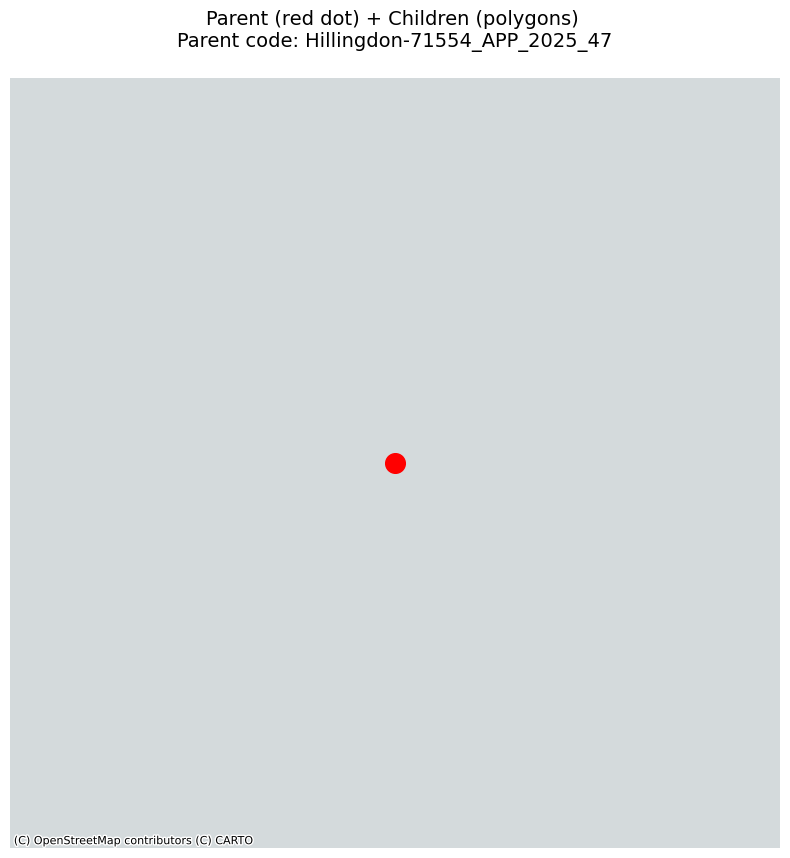

In [44]:
# Get a random parent set
parent_row, children = pick_parent_and_children(ldn_filtr_gdf)
parent_code = parent_row["id"]

# Build combined dataset (safe when children is empty)
parent_df = parent_row.to_frame().T

parts = [parent_df]
if children is not None and not children.empty:
    parts.append(children.reindex(columns=parent_df.columns))

to_plot = pd.concat(parts, axis=0)
to_plot = gpd.GeoDataFrame(to_plot, geometry="geometry", crs=ldn_filtr_gdf.crs)

# Reproject to Web Mercator
to_plot_web = to_plot.to_crs(3857)

# Split into geometry types
poly_mask = to_plot_web.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
point_mask = to_plot_web.geometry.geom_type == "Point"

parent_poly = to_plot_web[(poly_mask) & (to_plot_web["id"] == parent_code)]
parent_point = to_plot_web[(point_mask) & (to_plot_web["id"] == parent_code)]

children_poly = to_plot_web[(poly_mask) & (to_plot_web["id"] != parent_code)]
children_point = to_plot_web[(point_mask) & (to_plot_web["id"] != parent_code)]

fig, ax = plt.subplots(figsize=(10, 10))

# Children polygons
if not children_poly.empty:
    children_poly.plot(
        ax=ax, alpha=0.5, edgecolor="black", facecolor="lightblue"
    )

# Children points
if not children_point.empty:
    children_point.plot(
        ax=ax, color="blue", markersize=50, alpha=0.3
    )

# Parent polygon (highlighted)
if not parent_poly.empty:
    parent_poly.plot(
        ax=ax, alpha=0.4, edgecolor="red", facecolor="yellow"
    )

# Parent point (highlighted)
if not parent_point.empty:
    parent_point.plot(
        ax=ax, color="red", markersize=80
    )

# Always plot centroid so parent is visible
parent_centroid = parent_row.geometry.centroid
gpd.GeoSeries([parent_centroid], crs=ldn_filtr_gdf.crs).to_crs(3857).plot(
    ax=ax, color="red", markersize=200, zorder=20
)

# Auto fit
minx, miny, maxx, maxy = to_plot_web.total_bounds
buffer = 100   # smaller buffer for tiny polygons
ax.set_xlim(minx - buffer, maxx + buffer)
ax.set_ylim(miny - buffer, maxy + buffer)

#  add basemap after setting limits
ctx.add_basemap(
    ax,
    crs=to_plot_web.crs,
    source=ctx.providers.CartoDB.Positron,
    zoom=18   # safe maximum for this provider
)

geom_display = parent_poly.geometry.values if not parent_poly.empty else parent_point.geometry.values

ax.set_title(
    f"Parent (red dot) + Children (polygons) \n"
    f"Parent code: {parent_code}\n",
    # f"Parent geom: {geom_display}",
    fontsize=14
)

ax.set_axis_off()
plt.show()

In [45]:
# ldn_filtr_gdf[ldn_filtr_gdf["uid"]==325]

In [46]:
print(f"There are {ldn_filtr_gdf["parent_id"].isna().sum() - len(ldn_filtr_gdf[ldn_filtr_gdf["is_parent"]==True])} children that don't belong to any parent (orphans). Eiter they are all pre-apps, or indicate missing data.")

There are 160 children that don't belong to any parent (orphans). Eiter they are all pre-apps, or indicate missing data.


In [47]:
#___________________________________________________________________________________
# Let's group the children
#___________________________________________________________________________________

ldn_filtr_gdf["child_group"] = pd.NA

mask_has_parent = ldn_filtr_gdf["parent_id"].notna()

# assign group numbers for each parent_id (start at 1)
ldn_filtr_gdf.loc[mask_has_parent, "child_group"] = (
    ldn_filtr_gdf.loc[mask_has_parent].groupby("parent_id", sort=False).ngroup() + 1
    ).astype("Int64")  # nullable integer

In [48]:
#___________________________________________________________________________________
# Find groups without parent, or individual applications
#___________________________________________________________________________________

# Orphans: children that still have no group
orph_mask = (ldn_filtr_gdf["is_parent"] == False) & (ldn_filtr_gdf["child_group"].isna())
orphans = ldn_filtr_gdf.loc[orph_mask].copy()

if not orphans.empty:
    # spatial index on orphans
    sidx = orphans.sindex
    orphan_idx = list(orphans.index)

    # union-find (disjoint set)
    parent = {i: i for i in orphan_idx}
    rank = {i: 0 for i in orphan_idx}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra == rb:
            return
        if rank[ra] < rank[rb]:
            parent[ra] = rb
        elif rank[ra] > rank[rb]:
            parent[rb] = ra
        else:
            parent[rb] = ra
            rank[ra] += 1

    # build unions by intersects
    for i, geom in zip(orphans.index, orphans.geometry):
        # candidates by bbox
        cand_pos = list(sidx.intersection(geom.bounds))
        if not cand_pos:
            continue
        cand = orphans.iloc[cand_pos]
        # real intersects
        hits = cand[cand.geometry.intersects(geom)]
        for j in hits.index:
            if j != i:
                union(i, j)

    # map root -> component members
    comp = {}
    for i in orphan_idx:
        r = find(i)
        comp.setdefault(r, []).append(i)

    # next available group number (don’t reuse)
    existing_max = ldn_filtr_gdf["child_group"].max()
    next_group = int(existing_max) + 1 if pd.notna(existing_max) else 1

    # assign a new group id per component
    # only for components with more than one member (real groups)
    for _, members in comp.items():
        if len(members) <= 1:
            continue  # leave standalone orphans with child_group = NaN
        ldn_filtr_gdf.loc[members, "child_group"] = next_group
        next_group += 1

    # keep nullable int dtype
    ldn_filtr_gdf["child_group"] = ldn_filtr_gdf["child_group"].astype("Int64")

In [49]:
ldn_filtr_gdf["is_orphan"] = (
    (ldn_filtr_gdf["is_parent"] == False) &
    (ldn_filtr_gdf["parent_id"].isna())
)

In [50]:
ldn_filtr_gdf["is_orphan"].value_counts()

is_orphan
False    319
True     160
Name: count, dtype: int64

In [51]:
print(f"There are {ldn_filtr_gdf["child_group"].isna().sum() - len(ldn_filtr_gdf[ldn_filtr_gdf["is_parent"]==True])} orphans that are not part of any group.")

There are 61 orphans that are not part of any group.


In [52]:
#___________________________________________________________________________________
# I reduce the size of the dataframe for validation
#___________________________________________________________________________________
validation_is_informative_orphan = ldn_filtr_gdf[ldn_filtr_gdf["is_orphan"] == True].copy()

# For validation, keep columns that have at least 50% non-NaN values
threshold = 0.5
min_non_na = int(threshold * len(validation_is_informative_orphan))
validation_is_informative_orphan = validation_is_informative_orphan.dropna(axis=1, thresh=min_non_na)

#___________________________________________________________________________________
# Exporting for manual validation step 3 (performed in a separate ipynb )
#___________________________________________________________________________________
validation_is_informative_orphan.to_file(
    "validation_is_informative_orphan_source.gpkg",
    layer="validation_is_informative_orphan",
    driver="GPKG"
)

The validation revealed that a few orphans were in fact belonging to one of the parents, but were not matched initially due to incorrect geometry data. Since we are interested in parents, these orphans were not matched to them to reduce the workload.

In [53]:
validation_is_informative_orphan = pd.read_csv(
    "validation_is_informative_orphan_output.csv", na_values=["NULL", "null", "None", "", "[]"])

In [54]:
# validation_is_informative_orphan.info()

In [55]:
#___________________________________________________________________________________
# Merging validation with the existing dataframe by id
#___________________________________________________________________________________

# Merge validated values onto main df by BOTH keys
tmp = ldn_filtr_gdf.merge(
    validation_is_informative_orphan[["id", "useful_orphan"]].rename(columns={"useful_orphan": "useful_orphan_validated"}),
    on="id",
    how="left",
)

has_val = tmp["useful_orphan_validated"].notna()
tmp.loc[has_val, "useful_orphan"] = tmp.loc[has_val, "useful_orphan_validated"]

ldn_filtr_gdf = tmp.drop(columns=["useful_orphan_validated"])

In [56]:
ldn_filtr_gdf["useful_orphan"].value_counts()

useful_orphan
False    149
True       7
Name: count, dtype: int64

# Exporting for the manual input stage

At this stage I take a subset of the filtered dataframe that includes only full planning applications for the data centres, and several other applications that could point to the existing data centres. I analyse the utilisation of the initial column set, and remove those that have high % of NA results.

Finally, I make an export of the reduced dataframe to proceed with the manual lookup on the planning portals.

In [57]:
ldn_ful_gdf = ldn_filtr_gdf[(ldn_filtr_gdf["useful_orphan"] == True) | (ldn_filtr_gdf["is_parent"] == True)].copy()

In [58]:
cols_to_merge = [
    f"application_details_existing_proposed_floorspace_details_{i}" for i in range(11)
] #these columns i need to preserve

# Create a new column with list of values
ldn_ful_gdf["floorspace_details_combined"] = ldn_ful_gdf[cols_to_merge].values.tolist()

# Drop the original columns from the filtered DataFrame
ldn_ful_gdf = ldn_ful_gdf.drop(columns=cols_to_merge)

ldn_ful_gdf = ldn_ful_gdf.drop(
    columns=[col for col in ldn_ful_gdf.columns if col.startswith("application_details_residential_")]
) #these columns are mostly null or 0

In [59]:
ldn_ful_gdf.shape

(82, 177)

In [60]:
pd.set_option('display.max_rows', 500)

In [61]:
ldn_ful_gdf.isna().sum().sort_values()

lpa_name                                                                                              0
is_orphan                                                                                             0
is_child                                                                                              0
is_parent                                                                                             0
geometry                                                                                              0
geometry_point                                                                                        0
is_full_planning                                                                                      0
borough                                                                                               0
application_type                                                                                      0
last_synced                                                     

In [62]:
import plotly.express as px

s = ldn_ful_gdf.isna().sum().sort_values()

# Convert to DataFrame
df_nan = pd.DataFrame({
    "Column": s.index,
    "NaN Count": s.values
})

fig = px.line(
    df_nan,
    x="Column",
    y="NaN Count",
    labels={"Column": "Column name", "NaN Count": "Number of NaN values"},
    title="NaN counts per column (sorted)"
)

fig.update_traces(mode="lines+markers")

# Hide x-axis tick labels
fig.update_layout(
    xaxis=dict(showticklabels=False),
    template="plotly_white"
)

fig.show()

In [63]:
56 / (len(ldn_ful_gdf)/100)

68.29268292682927

In [64]:
#_____________________________________________________________________________________________________________________
# I reduce the size of the dataframe using the chart above as a guide
#_____________________________________________________________________________________________________________________

# threshold = 1 - 56 / (len(ldn_ful_gdf)/100)
# min_non_na = int(threshold * len(ldn_ful_gdf))
min_non_na = 32

ldn_ful_gdf = ldn_ful_gdf.dropna(axis=1, thresh=min_non_na)

# # List of columns exempt from being dropped
# exempt_cols = ["url_planning_app", ]  # example list

# # Columns that would be dropped by dropna
# cols_to_drop = [
#     col for col in ldn_ful_gdf.columns
#     if col not in exempt_cols and ldn_ful_gdf[col].count() < min_non_na
# ]

In [65]:
ldn_ful_gdf.shape

(82, 43)

In [66]:
ldn_ful_gdf.head(3)

,lpa_name,uprn,decision_date,application_type_full,bo_system,id,postcode,valid_date,description,last_updated,ward,lapsed_date,decision_target_date,centroid,lpa_app_no,status,site_name,url_planning_app,development_type,decision_process,decision_agency,last_synced,site_number,application_type,street_name,pp_id,cil_liability,borough,decision,application_details_building_details,application_details_site_area,application_details_non_residential_details_site_area,application_details_non_residential_details_total_non_resi_gross_internal_floor_area_to_be_lost,application_details_non_residential_details_total_gia_gained,application_details_non_residential_details_total_gia_lost,application_details_non_residential_details_total_non_resi_gross_internal_floor_area_to_be_gained,is_full_planning,geometry_point,geometry,is_parent,is_child,is_orphan,floorspace_details_combined
0,Barking & Dagenham,100101450,12/09/2018,Full planning permission,Idox Tascomi,Barking_&_Dagenham-18_00161_FUL,NaN,05/02/2018,"Erection of two data centre buildings (Use Class B8), with ancillary plant, offices, gatehouse, electrical sub-stations, fuel storage, car parking, site fencing, landscaping an...",2025-03-20T18:57:14.569+00:00,Eastbrook,12/09/2023,07/05/2018,"{'lat': 49.766807, 'lon': -7.55716}",18/00161/FUL,Lapsed,London East Business And Technical Park,https://online-befirst.lbbd.gov.uk/planning/index.html?fa=getApplication&id=15772,Major offices-R and D-light industry,Committee,NaN,2025-04-09T06:10:28.578Z,NaN,All Other,YEWTREE AVENUE,NaN,True,London Borough of Barking and Dagenham,Approved,NaN,0.000,NaN,0.0,0.0,0.0,52797.0,True,POINT (-7.55716 49.766807),"POLYGON ((550745 185653.291, 550760.214 185448.365, 550779.396 185449.026, 550847.408 185454.318, 550878.496 185460.932, 550905.616 185460.932, 550943.981 185464.24, 550985.653...",True,False,False,"[{'gia_existing': -1, 'superseded_date': None, 'actual_completion_date': None, 'use_class': 'B2', 'gia_gained': 0, 'actual_commencement_date': None, 'superseded_by_lpa_app_no':..."
12,Bexley,010011862607,02/10/2023,Full planning permission,Idox Uniform,Bexley-23_00960_FUL,DA8 1EW,27/04/2023,"Installation of 8 new dry coolers, a generator, transformer, plant container and associated works and pond to the existing data centre.",2025-03-19T22:26:55.098+00:00,ERITHN,02/10/2026,22/06/2023,"{'lat': 51.4915, 'lon': 0.166692}",23/00960/FUL,Approved,Unit 8,NaN,NaN,NaN,NaN,2025-04-09T04:22:46.653Z,NaN,All Other,Viking Way,PP-12028698,False,London Borough of Bexley,Approved,NaN,0.030,NaN,0.0,0.0,0.0,0.0,True,POINT (0.166692 51.4915),"POLYGON ((550516.58 179177.444, 550516.599 179174.439, 550513.545 179174.349, 550513.595 179177.355, 550516.58 179177.444))",True,False,False,"[{'gia_existing': 4104, 'superseded_date': None, 'actual_completion_date': None, 'use_class': 'B8', 'gia_gained': 0, 'actual_commencement_date': None, 'superseded_by_lpa_app_no..."
20,Bromley,010003628052,03/04/2020,NaN,Idox Uniform,Bromley-19_04182_FULL1,BR5 2UB,25/11/2019,Alterations and additions to existing building including replacement roof and wall cladding to facilitate a data/records processing/management centre (Mixed Use Class B1/B2/B8)...,2025-03-21T01:29:34.314+00:00,CRAYVE,03/04/2023,20/01/2020,"{'lon': '0.10776809999999999', 'lat': '51.3927088'}",19/04182/FULL1,Approved,Stanbridge Limited,NaN,NaN,Delegated,NaN,2025-04-09T05:07:18.438Z,NaN,All Other,Cray Valley Road,PP-08130427,False,LB Bromley,Approved,NaN,0.149,NaN,NaN,NaN,NaN,NaN,True,POINT (0.1077681 51.3927088),"POLYGON ((546740.4 168042.85, 546736.5 168041.45, 546732.4 168053.65, 546730.9 168058.05, 546727.4 168068.6, 546727.3 168068.9, 546727.15 168069.35, 546725.2 168071.2, 546723.8...",True,False,False,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]"


In [67]:
#___________________________________________________________________________________
# Exporting for manual fill in. I am dropping the geometry and helper columns
#___________________________________________________________________________________

ldn_ful_gdf_essential = ldn_ful_gdf.drop(axis=1, columns=["bo_system", "centroid","pp_id", "geometry_point",
                                                          "geometry","is_parent", "is_child", "is_orphan" ])

ldn_ful_gdf_essential.to_csv("ldn_ful_gdf_essential.csv", index=False)

In [74]:
ldn_ful_gdf_essential_ed1 = pd.read_csv(
    "ldn_ful_gdf_essential_ed1.csv", na_values=["NULL", "null", "None", "", "[]"])

In [75]:
#___________________________________________________________________________________
# Merging validation with the existing dataframe by id
#___________________________________________________________________________________
# Outer merge to include all rows from both DataFrames
merged = ldn_ful_gdf.merge(
    ldn_ful_gdf_essential_ed1,
    on="id",
    how="outer",
    suffixes=("", "_essential")
)

# For columns present in both but potentially conflicting, prefer values from the essential dataset
# Loop through essential columns (excluding 'id'), and overwrite if the '_essential' version exists
for col in ldn_ful_gdf_essential_ed1.columns:
    if col != "id" and f"{col}_essential" in merged.columns:
        merged[col] = merged[f"{col}_essential"].combine_first(merged[col])
        merged.drop(columns=[f"{col}_essential"], inplace=True)

# Final result: overwrite + additional rows added
ldn_ful_gdf = merged

In [ ]:
ldn_ful_gdf = ldn_ful_gdf.drop(axis=1, columns=[
    'valid_date','ward','lapsed_date','decision_target_date','bo_system','application_type_full',
    'status', 'site_name','development_type','decision_process','decision_agency',
'last_synced',
 'site_number','application_type',
 'street_name',
 'pp_id',
 'cil_liability','borough',
 'decision',
 'application_details_building_details','application_details_non_residential_details_total_non_resi_gross_internal_floor_area_to_be_lost',
 'application_details_non_residential_details_total_gia_gained',
 'application_details_non_residential_details_total_gia_lost',
 'application_details_non_residential_details_total_non_resi_gross_internal_floor_area_to_be_gained',
 'is_full_planning', 'floorspace_details_combined','Google',
])

In [79]:
ldn_ful_gdf.columns.to_list()

['lpa_name',
 'uprn',
 'decision_date',
 'application_type_full',
 'bo_system',
 'id',
 'postcode',
 'valid_date',
 'description',
 'last_updated',
 'ward',
 'lapsed_date',
 'decision_target_date',
 'centroid',
 'lpa_app_no',
 'status',
 'site_name',
 'url_planning_app',
 'development_type',
 'decision_process',
 'decision_agency',
 'last_synced',
 'site_number',
 'application_type',
 'street_name',
 'pp_id',
 'cil_liability',
 'borough',
 'decision',
 'application_details_building_details',
 'application_details_site_area',
 'application_details_non_residential_details_site_area',
 'application_details_non_residential_details_total_non_resi_gross_internal_floor_area_to_be_lost',
 'application_details_non_residential_details_total_gia_gained',
 'application_details_non_residential_details_total_gia_lost',
 'application_details_non_residential_details_total_non_resi_gross_internal_floor_area_to_be_gained',
 'is_full_planning',
 'geometry_point',
 'geometry',
 'is_parent',
 'is_child',
 

In [80]:
ldn_ful_gdf.head(3)

,lpa_name,uprn,decision_date,application_type_full,bo_system,id,postcode,valid_date,description,last_updated,ward,lapsed_date,decision_target_date,centroid,lpa_app_no,status,site_name,url_planning_app,development_type,decision_process,decision_agency,last_synced,site_number,application_type,street_name,pp_id,cil_liability,borough,decision,application_details_building_details,application_details_site_area,application_details_non_residential_details_site_area,application_details_non_residential_details_total_non_resi_gross_internal_floor_area_to_be_lost,application_details_non_residential_details_total_gia_gained,application_details_non_residential_details_total_gia_lost,application_details_non_residential_details_total_non_resi_gross_internal_floor_area_to_be_gained,is_full_planning,geometry_point,geometry,is_parent,is_child,is_orphan,floorspace_details_combined,action,notes,enterprise,current_occupier,Google,website,Address,Easting,Northing,completed,data_centre_since,SIL,B8_no_storeys,B8_max_height_m,B8_gia_sqm,Other_use_classes_present_within_B8_building,B8_total_staff_FTE,Security_staff,Site_engineers_staff,Managers_staff,Cleaners_staff,Visitor_staff_not_on_site,Cluster_staff_not_on_site,B8_employees_at_a_day
0,Barking & Dagenham,100101450,12/09/2018,Full planning permission,Idox Tascomi,Barking_&_Dagenham-18_00161_FUL,RM10 7XS,05/02/2018,"Erection of two data centre buildings (Use Class B8), with ancillary plant, offices, gatehouse, electrical sub-stations, fuel storage, car parking, site fencing, landscaping an...",2025-03-20T18:57:14.569+00:00,Eastbrook,12/09/2023,07/05/2018,"{'lat': 49.766807, 'lon': -7.55716}",18/00161/FUL,Lapsed,London East Business And Technical Park,https://online-befirst.lbbd.gov.uk/planning/index.html?fa=getApplication&id=15772,Major offices-R and D-light industry,Committee,NaN,2025-04-09T06:10:28.578Z,NaN,All Other,YEWTREE AVENUE,NaN,True,London Borough of Barking and Dagenham,Approved,NaN,7.54,NaN,0.0,"52,797.30",0.0,"52,797.30",True,POINT (-7.55716 49.766807),"POLYGON ((550745 185653.291, 550760.214 185448.365, 550779.396 185449.026, 550847.408 185454.318, 550878.496 185460.932, 550905.616 185460.932, 550943.981 185464.24, 550985.653...",True,False,False,"[{'gia_existing': -1, 'superseded_date': None, 'actual_completion_date': None, 'use_class': 'B2', 'gia_gained': 0, 'actual_commencement_date': None, 'superseded_by_lpa_app_no':...",keep,"Construction of 2 No. Data Centres (9,263 and 14,490 square metres GEA)",NaN,NTT Data Centre,NaN,https://services.global.ntt/en-us/services-and-products/global-data-centers/global-locations/emea/london-1-data-center,"London East Business And Technical Park Yewtree Avenue, Dagenham, Barking And Dagenham, RM10 7XS",NaN,NaN,Completed,2025.0,NaN,3.0,17300.00,"52,797.30",NaN,110.0,14.0,66.0,30.0,NaN,40.0,NaN,62.0
1,Bexley,010011862607,02/10/2023,Full planning permission,Idox Uniform,Bexley-23_00960_FUL,DA8 1EW,27/04/2023,"Installation of 8 new dry coolers, a generator, transformer, plant container and associated works and pond to the existing data centre.",2025-03-19T22:26:55.098+00:00,ERITHN,02/10/2026,22/06/2023,"{'lat': 51.4915, 'lon': 0.166692}",23/00960/FUL,Approved,Unit 8,https://pa.bexley.gov.uk/online-applications/simpleSearchResults.do?action=firstPage,NaN,NaN,NaN,2025-04-09T04:22:46.653Z,NaN,All Other,Viking Way,PP-12028698,False,London Borough of Bexley,Approved,NaN,0.03,NaN,0.0,4104,0.0,4104,True,POINT (0.166692 51.4915),"POLYGON ((550516.58 179177.444, 550516.599 179174.439, 550513.545 179174.349, 550513.595 179177.355, 550516.58 179177.444))",True,False,False,"[{'gia_existing': 4104, 'superseded_date': None, 'actual_completion_date': None, 'use_class': 'B8', 'gia_gained': 0, 'actual_commencement_date': None, 'superseded_by_lpa_app_no...",keep,"Built earlier in 2017, see 16/03066/FUL",NaN,OVH,NaN,NaN,"Unit 8, Viking Way, Erith, Kent, DA8 1EW",NaN,NaN,Completed,2017.0,NaN,2.0,7.00,4104,NaN,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Brent,NaN,01/03/2024,Full pla

In [ ]:
#___________________________________________________________________________________
# Exporting for manual validation step 3 (performed in a separate ipynb )
#___________________________________________________________________________________
validation_is_informative_orphan.to_file(
    "validation_is_informative_orphan_source.gpkg",
    layer="validation_is_informative_orphan",
    driver="GPKG"
)

In [ ]:
# pre_app_type = ["Outline planning permission: All matters reserved", "Outline planning permission: Some matters reserved ", "Prior Approval: Demolition of building "]
# ldn_filtr_gdf["is_full_planning"] = (
#     ldn_filtr_gdf["application_type_full"]
#         .isin(pre_app_type)
#         .where(ldn_filtr_gdf["application_type_full"].notna(), pd.NA)
# )

In [ ]:
mask_has_parent = ldn_filtr_gdf["parent_uid"].notna()

In [68]:
ldn_filtr_gdf["application_type_full"].value_counts()

application_type_full
Approval of details reserved by a condition (discharge)    101
Full planning permission                                    65
Non-Material Amendment                                      24
S73 Minor Material Amendment                                 9
Removal/Variation of a condition                             7
Outline planning permission: All matters reserved            5
Approval of reserved matters                                 4
Outline planning permission: Some matters reserved           2
S106 Deed of Variation                                       1
Prior Approval: Demolition of building                       1
Lawful development: Proposed use                             1
Full planning & listed building consent                      1
Full planning & demolition in a conservation area            1
Name: count, dtype: int64

In [67]:
ldn_filtr_gdf.head(3)

,lpa_name,uprn,decision_date,epc_number,application_type_full,bo_system,secondary_street_name,appeal_status,postcode,appeal_decision,valid_date,reference_no_of_permission_being_relied_on,description,decision_conditions,date_building_work_started_under_previous_permission,lapsed_date,decision_target_date,centroid,lpa_app_no,status,site_name,url_planning_app,locality,development_type,last_date_consultation_comments,appeal_decision_date,decision_process,decision_agency,date_building_work_completed_under_previous_permission,site_number,application_type,actual_completion_date,title_number,actual_commencement_date,street_name,pp_id,subdivision_of_building,cil_liability,appeal_start_date,decision,application_details_affordable_housing_inlieu_payment,application_details_superseding_details,application_details_building_age,application_details_no_affordable_housing_units_provided_offsite,application_details_building_type,application_details_no_affordable_housing_units_acquired_offsite,application_details_occupation_status,application_details_scheme_name,application_details_non_permanent_dwellings_details,application_details_building_details,application_details_constraints_details,application_details_affordable_housing_fast_track,application_details_s106_agreement,application_details_air_quality_assessment,application_details_other_contributions,application_details_existing_uprns,application_details_intended_commencement_date,application_details_total_gia_existing,application_details_scheme_phasing,application_details_circular_economy_statement,application_details_commencement_notice_received,application_details_qualifying_vacant_building_floorspace,application_details_phasing_details,application_details_site_area,application_details_grey_water_reuse,application_details_surface_water_discharge_percentage_reduction,application_details_lead_registered_social_landlord,application_details_viability_assessment,application_details_overseas_company_registration_no,application_details_mayoral_cil_liability_notice_issued,application_details_intended_completion_date,application_details_projected_cost_of_works,application_details_uk_company_registration_no,application_details_internal_resi_water_usage,application_details_3d_model,application_details_transport_contributions,application_details_total_gia_gained,application_details_borough_cil_liability_notice_issued,application_details_total_gia_lost,application_details_transport_impact_assessment,application_details_social_infrastructure_contributions,application_details_rain_water_harvesting,application_details_green_suds,application_details_garden_land_lost,application_details_ownership_status,application_details_lead_developer_company_name,application_details_other_residential_accommodation_details_no_council_tax_rateable_units_lost,application_details_other_residential_accommodation_details_other_resi_accommodation_unit_details,application_details_other_residential_accommodation_details_no_council_tax_rateable_units_gained,application_details_other_residential_accommodation_details_site_area,application_details_residential_details_affordable_percentage,application_details_residential_details_total_no_proposed_residential_units_london_shared_ownership,application_details_residential_details_total_no_proposed_residential_units_discount_market_rent,application_details_residential_details_dwelling_density,application_details_residential_details_total_no_proposed_residential_units_affordable_rent,application_details_residential_details_total_no_existing_residential_units_market_for_sale,application_details_residential_details_total_no_proposed_residential_units_market_for_sale,application_details_residential_details_total_no_existing_residential_units_london_affordable_rent,application_details_residential_details_total_no_existing_residential_units_discount_market_rent,application_details_residential_details_total_no_proposed_residential_units_social_rent,application_details_residential_details_total

In [413]:
ldn_filtr_gdf["child_group"].isna().sum()

np.int64(69)

In [409]:
test = ldn_filtr_gdf[
    (ldn_filtr_gdf["is_child"] == True) &
    (ldn_filtr_gdf["is_parent"] == True)
]

In [ ]:
# APPROVED = {"Approved", "Completed", "Allowed"}

# df = ldn_filtr

# # --- split parents and children ---
# parents = df[df["is_full_planning"] == True][
#     ["lpa_app_no", "status", "decision_date"]
# ].rename(
#     columns={
#         "status": "parent_status",
#         "decision_date": "parent_decision_date",
#     }
# )

# children = df[df["is_child"] == True][
#     ["parent_ref", "status", "decision_date"]
# ].rename(
#     columns={
#         "status": "child_status",
#         "decision_date": "child_decision_date",
#     }
# )

# # --- keep only approved children ---
# children = children[children["child_status"].isin(APPROVED)]

# # --- join children to their parents to compare dates ---
# child_parent = children.merge(
#     parents,
#     left_on="parent_ref",
#     right_on="lpa_app_no",
#     how="inner",
# )

# # --- child decided AFTER parent ---
# child_parent = child_parent[
#     child_parent["child_decision_date"] > child_parent["parent_decision_date"]
# ]

# # --- parents that are NOT approved ---
# bad_parents = parents[~parents["parent_status"].isin(APPROVED)]

# # --- parents with at least one qualifying child ---
# result = bad_parents[
#     bad_parents["lpa_app_no"].isin(child_parent["lpa_app_no"])
# ]

# # --- final count ---
# n = result["lpa_app_no"].nunique()
# n

In [118]:
# ldn_filtr["status"].value_counts()

status
Approved                                   271
No Objection to Proposal (OBS only)         30
Completed                                   23
Application Under Consideration             22
Insufficient Fee                            22
Withdrawn                                   18
Closed                                      17
Lapsed                                      12
Unknown                                      8
Commenced                                    7
Refused                                      6
Application Received                         6
Opinion Issued                               5
Declined to Determine                        5
                                             4
Objection Raised to Proposal (OBS only)      3
Superseded                                   2
Screen/Scope Issued                          1
Dismissed                                    1
Comment Issued                               1
                                             1
Appeal

In [108]:
# ldn_filtr["is_full_planning"].value_counts()

is_full_planning
False    351
True      63
Name: count, dtype: int64

In [ ]:
# ldn_filtr[ldn_filtr["is_full_planning"] == True]["url_planning_app"].isna().value_counts()

In [109]:
# # checking and dropping the identical rows
# # Count non-null values per row
# ldn_filtr['non_null_count'] = ldn_filtr.notna().sum(axis=1)

# # Keep only the row with the most non-null columns per 'lpa_app_no'
# ldn_filtr_gdf_unique = (
#     ldn_filtr_gdf.sort_values('non_null_count', ascending=False)
#     .groupby('lpa_app_no', as_index=False)
#     .first()
# )

# # Drop the helper column
# ldn_filtr_gdf = ldn_filtr_gdf_unique.drop(columns=['non_null_count'])

# print(ldn_filtr_gdf.shape)

In [110]:
# 

In [114]:
ldn_filtr_gdf["is_child"].value_counts()

is_child
True     245
False    234
Name: count, dtype: int64

In [126]:
# Find duplicated lpa_app_no (both first and subsequent occurrences)
duplicated_mask = ldn_filtr_gdf["lpa_app_no"].duplicated(keep=False)

# Select only the duplicated rows
duplicated_rows = ldn_filtr_gdf[duplicated_mask]
duplicated_rows_sorted = duplicated_rows.sort_values("lpa_app_no")

duplicated_rows_sorted

lpa_name          uprn decision_date epc_number  \
512  Richmond  100022338319    22/09/2021        NaN   
536  Richmond  100022338319    22/09/2021        NaN   
514  Richmond  100023410516    28/02/2024        NaN   
538  Richmond  100023410516    28/02/2024        NaN   
91     Ealing  000012130533    25/07/2012        NaN   
144      OPDC           NaN    25/07/2012        NaN   
85     Ealing  000012130533    28/01/2015        NaN   
156      OPDC           NaN    28/01/2015        NaN   
104    Ealing  000012141021    27/03/2015        NaN   
158      OPDC           NaN    27/03/2015        NaN   

                                       application_type_full  \
512                                                      NaN   
536                                                      NaN   
514  Approval of details reserved by a condition (discharge)   
538  Approval of details reserved by a condition (discharge)   
91                                                       NaN   
144                                 Full planning permission   
85                                                       NaN   
156                             S73 Minor Material Amendment   
104                                                      NaN   
158                                 Full planning permission   

                  bo_system secondary_street_name appeal_status  postcode  \
512            Idox Uniform                   NaN           NaN   TW2 6LF   
536            Idox Uniform                   NaN           NaN   TW2 6LF   
514            Idox Uniform                   NaN           NaN   TW9 3AB   
538            Idox Uniform                   NaN           NaN   TW9 3AB   
91          CSV Data Import                   NaN           NaN    W3 0TA   
144  FME Legacy Data Import                   NaN           NaN    W3 0TA   
85          CSV Data Import                   NaN           NaN    W3 0TA   
156  FME Legacy Data Import                   NaN           NaN    W3 0TA   
104         CSV Data Import                   NaN           NaN  NW10 6PW   
158  FME Legacy Data Import                   NaN           NaN  NW10 6PW   

    appeal_decision  valid_date reference_no_of_permission_being_relied_on  \
512             NaN  08/07/2021                                        NaN   
536             NaN  08/07/2021                                        NaN   
514             NaN  16/01/2024                                        NaN   
538             NaN  16/01/2024                                        NaN   
91              NaN  18/08/2011                                        NaN   
144             NaN         NaN                                        NaN   
85              NaN  07/10/2014                                        NaN   
156             NaN         NaN                                        NaN   
104             NaN  30/01/2015                                        NaN   
158             NaN         NaN                                        NaN   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [116]:
duplicated_rows.shape

(10, 218)

In [121]:
APPROVED = {"Approved", "Completed", "Allowed"}

df = ldn_filtr

# --- split parents and children ---
parents = df[df["is_full_planning"] == True][
    ["lpa_app_no", "status", "decision_date"]
].rename(
    columns={
        "status": "parent_status",
        "decision_date": "parent_decision_date",
    }
)

children = df[df["is_child"] == True][
    ["parent_ref", "status", "decision_date"]
].rename(
    columns={
        "status": "child_status",
        "decision_date": "child_decision_date",
    }
)

# --- keep only approved children ---
children = children[children["child_status"].isin(APPROVED)]

# --- join children to their parents to compare dates ---
child_parent = children.merge(
    parents,
    left_on="parent_ref",
    right_on="lpa_app_no",
    how="inner",
)

# --- child decided AFTER parent ---
child_parent = child_parent[
    child_parent["child_decision_date"] > child_parent["parent_decision_date"]
]

# --- parents that are NOT approved ---
bad_parents = parents[~parents["parent_status"].isin(APPROVED)]

# --- parents with at least one qualifying child ---
result = bad_parents[
    bad_parents["lpa_app_no"].isin(child_parent["lpa_app_no"])
]

# --- final count ---
n = result["lpa_app_no"].nunique()
n

3

In [123]:
summary = (
    child_parent.groupby("lpa_app_no")
    .size()
    .rename("n_approved_children_after_parent")
    .reset_index()
    .merge(
        bad_parents[["lpa_app_no", "parent_status", "parent_decision_date"]],
        on="lpa_app_no",
        how="left",
    )
    .sort_values("n_approved_children_after_parent", ascending=False)
)

summary.head(20)

,lpa_app_no,n_approved_children_after_parent,parent_status,parent_decision_date
0,1331/APP/2017/1883,7,Superseded,28/06/2018
1,18399/APP/2022/411,4,NaN,NaN
2,191968FUL,4,NaN,NaN
3,38421/APP/2021/4045,3,NaN,NaN
4,P/2000/1917,2,NaN,NaN
5,P/2011/3529,1,NaN,NaN
6,P2021/1732/COLP,1,Insufficient Fee,09/08/2021
7,PA/21/00697/NC,1,Lapsed,12/05/2021


In [124]:
APPROVED = {"Approved", "Completed", "Allowed"}

df = ldn_filtr_gdf
parent_id = "P2021/1732/COLP"

# --- parent row ---
parent = df[df["lpa_app_no"] == parent_id]

print("PARENT:")
print(parent)
print("\n")

# --- approved children decided after parent ---
children = (
    df[
        (df["is_child"] == True) &
        (df["parent_ref"] == parent_id) &
        (df["status"].isin(APPROVED))
    ]
    .merge(
        parent[["lpa_app_no", "decision_date"]],
        left_on="parent_ref",
        right_on="lpa_app_no",
        suffixes=("", "_parent"),
    )
)

children = children[
    children["decision_date"] > children["decision_date_parent"]
]

print("APPROVED CHILDREN (decided after parent):")
print(children)


PARENT:
      lpa_name        uprn decision_date epc_number  \
486  Islington  5300069637    09/08/2021        NaN   

                application_type_full   bo_system secondary_street_name  \
486  Lawful development: Proposed use  Agile APAS                   NaN   

    appeal_status postcode appeal_decision  valid_date  \
486           NaN      NaN             NaN  14/06/2021   

    reference_no_of_permission_being_relied_on  \
486                                        NaN   

                                                                                                                           description  \
486  Certificate of Lawfulness (Proposed) for a Data Centre (B8) to include the fitting out of the basement with data centre machinery   

                                                                                                                                                                                                                               decision_con

In [125]:
FULL_TYPES = {
    "Full planning permission",
    "Full planning & listed building consent",
    "Lawful development: Proposed use",
}

n_children = (
    ldn_filtr_gdf[
        (ldn_filtr_gdf["is_child"] == True) &
        (ldn_filtr_gdf["application_type_full"].isin(FULL_TYPES))
    ]
    .shape[0]
)

n_children


16

In [28]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx
import random

# 1 — Prepare data
subset = ldn_filtr_gdf.copy()
subset = subset.set_geometry("geometry")
subset = subset.set_crs(epsg=27700, inplace=False)   # BNG

# Identify parents
parents = subset[subset["is_full_planning"] == True].copy()

def pick_parent_and_children():
    """Randomly select parent & children — fallback to point geometry if needed."""
    parent = parents.sample(1).iloc[0]
    parent_code = parent["lpa_app_no"]

    children = subset[subset["parent_ref"] == parent_code]

    return parent, children


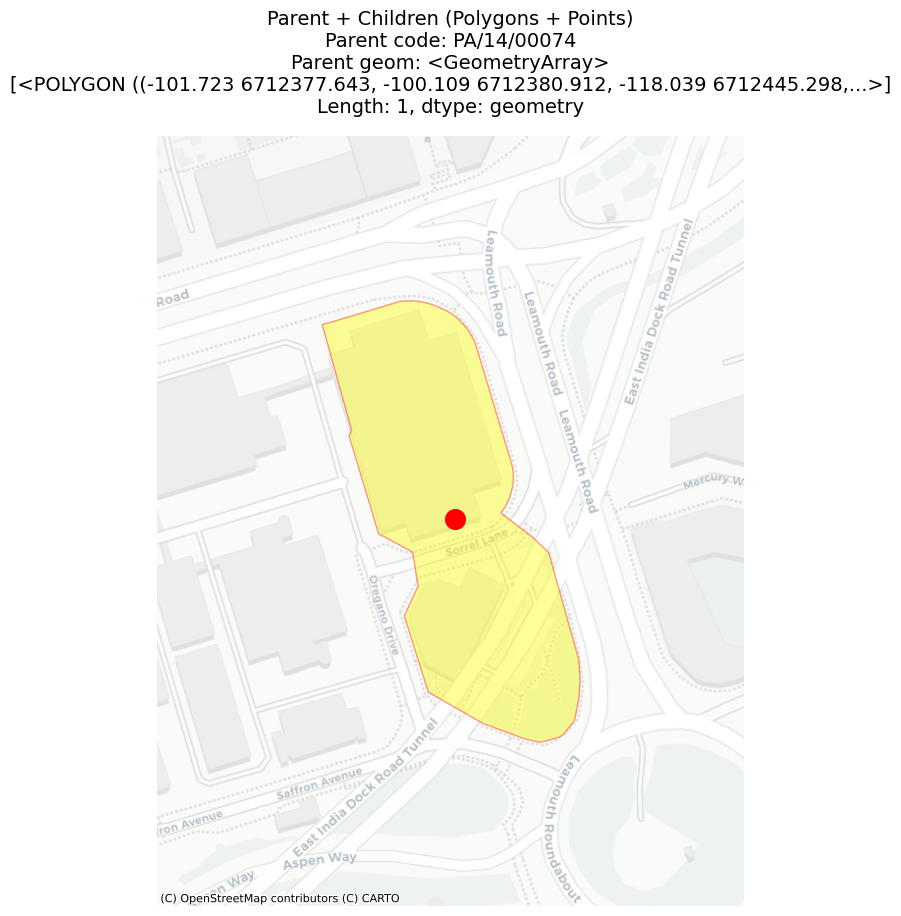

In [37]:
# --- Get a random parent set ---
parent_row, children = pick_parent_and_children()
parent_code = parent_row["lpa_app_no"]

# Build combined dataset
to_plot = pd.concat([parent_row.to_frame().T, children], axis=0)
to_plot = gpd.GeoDataFrame(to_plot, geometry="geometry", crs=subset.crs)

# Reproject to Web Mercator
to_plot_web = to_plot.to_crs(3857)

# Split into geometry types
poly_mask = to_plot_web.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
point_mask = to_plot_web.geometry.geom_type == "Point"

parent_poly = to_plot_web[(poly_mask) & (to_plot_web["lpa_app_no"] == parent_code)]
parent_point = to_plot_web[(point_mask) & (to_plot_web["lpa_app_no"] == parent_code)]

children_poly = to_plot_web[(poly_mask) & (to_plot_web["lpa_app_no"] != parent_code)]
children_point = to_plot_web[(point_mask) & (to_plot_web["lpa_app_no"] != parent_code)]

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 10))

# Children polygons
if not children_poly.empty:
    children_poly.plot(
        ax=ax, alpha=0.5, edgecolor="black", facecolor="lightblue"
    )

# Children points
if not children_point.empty:
    children_point.plot(
        ax=ax, color="blue", markersize=50, alpha=0.3
    )

# Parent polygon (highlighted)
if not parent_poly.empty:
    parent_poly.plot(
        ax=ax, alpha=0.4, edgecolor="red", facecolor="yellow"
    )

# Parent point (highlighted)
if not parent_point.empty:
    parent_point.plot(
        ax=ax, color="red", markersize=80
    )

# Always plot centroid so parent is visible
parent_centroid = parent_row.geometry.centroid
gpd.GeoSeries([parent_centroid], crs=subset.crs).to_crs(3857).plot(
    ax=ax, color="red", markersize=200, zorder=20
)

# Auto fit
minx, miny, maxx, maxy = to_plot_web.total_bounds
buffer = 100   # smaller buffer for tiny polygons
ax.set_xlim(minx - buffer, maxx + buffer)
ax.set_ylim(miny - buffer, maxy + buffer)

# Now add basemap AFTER setting limits
ctx.add_basemap(
    ax,
    crs=to_plot_web.crs,
    source=ctx.providers.CartoDB.Positron,
    zoom=18   # safe maximum for this provider
)


# ✔ FIXED THE F-STRING QUOTATION ERROR HERE
geom_display = parent_poly.geometry.values if not parent_poly.empty else parent_point.geometry.values

ax.set_title(
    f"Parent + Children (Polygons + Points)\n"
    f"Parent code: {parent_code}\n"
    f"Parent geom: {geom_display}",
    fontsize=14
)

ax.set_axis_off()
plt.show()

In [35]:
print("Parent code:", parent_code)
print("Geometry:", parent_row.geometry)
print("Geom type:", parent_row.geometry.geom_type if parent_row.geometry else None)
print("Is empty:", parent_row.geometry.is_empty if parent_row.geometry else None)
print("Bounds:", parent_row.geometry.bounds if parent_row.geometry else None)


Parent code: PP/2015/0516
Geometry: POLYGON ((521078.87823144713 182685.33158156363, 521078.8804789545 182682.32744312985, 521075.89798331825 182682.2563891902, 521075.8957376201 182685.2605276141, 521078.87823144713 182685.33158156363))
Geom type: Polygon
Is empty: False
Bounds: (521075.8957376201, 182682.2563891902, 521078.8804789545, 182685.33158156363)


In [63]:
# Find rows where geometry is invalid
# invalid_geom = ldn_filtr_gdf[~ldn_filtr_gdf["geometry"].is_valid | ldn_filtr_gdf["geometry"].is_empty]
# print(invalid_geom[["lpa_app_no", "polygon_dict", "wgs84_polygon_dict"]])

(161, 25)


/opt/conda/lib/python3.12/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [65]:
ldn_filtr_gdf.tail(1)

,lpa_app_no,lpa_name,uprn,decision_date,application_type_full,postcode,valid_date,description,decision_conditions,lapsed_date,decision_target_date,centroid,status,site_name,url_planning_app,decision_process,decision_agency,application_type,street_name,pp_id,cil_liability,decision,application_details_site_area,geometry_point,geometry_polygon
160,TP001640,Enfield,None,04/09/2001,Full planning permission,EN3,None,Redevelopment of site by the demolition of exi...,None,04/09/2006,None,"{'lon': -0.027031, 'lat': 51.659538}",Completed,59,None,None,Borough,All Other,LOCKFIELD AVENUE,None,None,Approved,NaN,POINT (536563.211 197481.767),POLYGON ((536564.6937412424 197483.25359054748...


In [66]:
ldn_filtr_gdf["lpa_name"].unique()

array(['Tower Hamlets', 'Kingston', 'Westminster', 'LLDC', 'Hillingdon',
       'Bexley', 'Ealing', 'Barking & Dagenham', 'Croydon', 'Bromley',
       'Newham', 'Brent', 'Hackney', 'Camden', 'Hammersmith & Fulham',
       'Barnet', 'Enfield', 'Southwark', 'Islington', 'OPDC', 'Hounslow',
       'Lewisham', 'Sutton', 'Havering'], dtype=object)

In [67]:
ldn_filtr_gdf = ldn_filtr_gdf.set_crs("EPSG:27700", allow_override=True)

In [68]:
ldn_filtr_gdf[ldn_filtr_gdf["lpa_name"] == "Barking & Dagenham"]

,lpa_app_no,lpa_name,uprn,decision_date,application_type_full,postcode,valid_date,description,decision_conditions,lapsed_date,decision_target_date,centroid,status,site_name,url_planning_app,decision_process,decision_agency,application_type,street_name,pp_id,cil_liability,decision,application_details_site_area,geometry_point,geometry_polygon
9,18/00161/FUL,Barking & Dagenham,100101450,12/09/2018,Full planning permission,None,05/02/2018,Erection of two data centre buildings (Use Cla...,['Piling using penetrative methods shall not b...,12/09/2023,07/05/2018,"{'lat': 49.766807, 'lon': -7.55716}",Lapsed,London East Business And Technical Park,https://online-befirst.lbbd.gov.uk/planning/in...,Committee,None,All Other,YEWTREE AVENUE,None,True,Approved,0.0,POINT (3.42 -0.233),"POLYGON ((550745 185653.291, 550760.214 185448..."


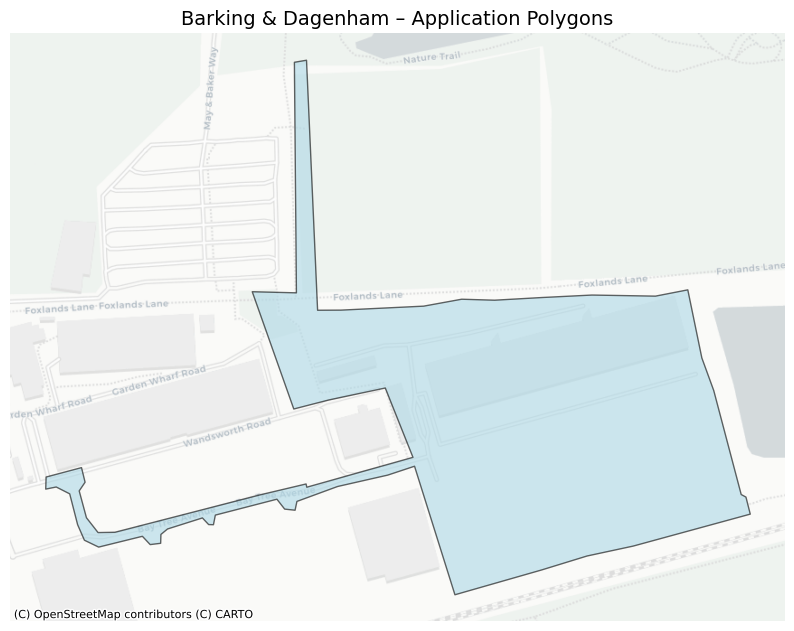

In [69]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

# --- 1. Select only Barking & Dagenham polygons ---
subset = ldn_filtr_gdf[ldn_filtr_gdf["lpa_name"] == "Barking & Dagenham"].copy()

# --- 2. Move polygon column into .geometry ---
subset = subset.set_geometry("geometry_polygon")

# Assign missing CRS (BGS: UK National Grid)
subset = subset.set_crs(epsg=27700, inplace=False)
subset_web = subset.to_crs(3857)

# --- 4. Plot with basemap ---
fig, ax = plt.subplots(figsize=(10, 10))

subset_web.plot(
    ax=ax,
    alpha=0.6,
    edgecolor="black",
    facecolor="lightblue"
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

ax.set_title("Barking & Dagenham – Application Polygons", fontsize=14)
ax.set_axis_off()

plt.show()

In [70]:
# # Convert geometry to WKT strings and save for validation
# ldn_filtr_gdf.assign(
#     geometry_wkt = ldn_filtr_gdf.geometry.apply(lambda g: g.wkt if g is not None else None)
# ).drop(columns=["geometry"]).to_csv("ldn_filtr_gdf.csv", index=False)

In [71]:
# ldn_filtr_gdf[ldn_filtr_gdf["lpa_app_no"]=="P/2008/3284"]

In [72]:
# ldn_filtr_gdf[ldn_filtr_gdf["lpa_app_no"].str.startswith("13/00534/FUM")]

In [73]:
# Importing the validation sheet
ldn_filtr_validated = pd.read_csv("ldn_filtr_validated.csv")

In [74]:
ldn_filtr_gdf = (ldn_filtr_gdf.merge(ldn_filtr_validated, on="lpa_app_no", how="left"))

In [75]:
ldn_filtr_gdf.tail(1)

,lpa_app_no,lpa_name,uprn,decision_date,application_type_full,postcode,valid_date,description,decision_conditions,lapsed_date,decision_target_date,centroid,status,site_name,url_planning_app,decision_process,decision_agency,application_type,street_name,pp_id,cil_liability,decision,application_details_site_area,geometry_point,geometry_polygon,classification
161,TP001640,Enfield,None,04/09/2001,Full planning permission,EN3,None,Redevelopment of site by the demolition of exi...,None,04/09/2006,None,"{'lon': -0.027031, 'lat': 51.659538}",Completed,59,None,None,Borough,All Other,LOCKFIELD AVENUE,None,None,Approved,NaN,POINT (536563.211 197481.767),POLYGON ((536564.6937412424 197483.25359054748...,new


In [76]:
# Filtering out the rows that didn't pass validation
ldn_filtr_gdf = ldn_filtr_gdf[~ldn_filtr_gdf["classification"].isnull()]

In [77]:
ldn_filtr_gdf.shape

(115, 26)

In [78]:
# ldn_filtr_gdf["decision"].value_counts()

In [79]:
ldn_filtr_gdf = ldn_filtr_gdf.set_crs("EPSG:27700", allow_override=True)

In [82]:
ldn_filtr_gdf[ldn_filtr_gdf["lpa_app_no"].str.contains(r"[A-Za-z]", na=False) == False]

# Anna you need to filter out planning applications without /

,lpa_app_no,lpa_name,uprn,decision_date,application_type_full,postcode,valid_date,description,decision_conditions,lapsed_date,decision_target_date,centroid,status,site_name,url_planning_app,decision_process,decision_agency,application_type,street_name,pp_id,cil_liability,decision,application_details_site_area,geometry_point,geometry_polygon,classification
0,000076,Tower Hamlets,None,19/04/2001,Full planning permission,E14,None,Erection of a 10-storey building for use as da...,None,19/04/2006,None,"{'lat': 51.510951, 'lon': -0.003496}",Completed,SITE BOUNDED BY,None,None,Borough,All Other,NUTMEG LANE,None,None,Approved,NaN,POINT (538642.125 181002.788),"POLYGON ((538643.6124232718 181004.2755851872,...",new
1,0101038,Tower Hamlets,None,01/02/2002,Full planning permission,E14 3AN,None,Change of use from B8 warehouse to data centre.,None,01/02/2007,None,"{'lat': 51.487797, 'lon': -0.015786}",Superseded,443-451,None,None,Borough,All Other,WESTFERRY ROAD,None,None,Approved,NaN,POINT (537859.197 178404.906),"POLYGON ((537860.6848163598 178406.3926903376,...",new
3,08/10204,Kingston,None,09/02/2009,Full planning permission,KT9 1SJ,None,Demolition of car parking deck. Erection of me...,None,09/02/2012,None,"{'lon': '-0.29079469999999996', 'lat': '51.368...",Lapsed,Fountain Court,None,None,Borough,All Other,Cox Lane,None,None,Approved,2.294,POINT (519077.003 164626.994),POLYGON ((518994.36725819367 164528.0154849089...,new
4,08/10204,Kingston,None,09/02/2009,Full planning permission,KT9 1SJ,None,Demolition of car parking deck. Erection of me...,None,09/02/2012,None,"{'lon': '-0.29079469999999996', 'lat': '51.368...",Lapsed,Fountain Court,None,None,Borough,All Other,Cox Lane,None,None,Approved,2.294,POINT (519077.003 164626.994),POLYGON ((518994.36725819367 164528.0154849089...,new
17,20/1828,Brent,202220669,02/10/2020,None,None,25/06/2020,Alterations and extensions to existing buildin...,None,02/10/2023,02/10/2020,"{'lat': 51.570777, 'lon': -0.236869}",Lapsed,"1-5 JVC Business Park & JVC House, 12 JVC Busi...",https://pa.brent.gov.uk/online-applications/ap...,Delegated,None,All Other,None,PP-08756197,True,Approved,3.436,POINT (522288.251 187239.633),"POLYGON ((522200.427 187144.304, 522201.4 1871...",existing
19,2000368,Hillingdon,None,15/08/2000,Full planning permission,UB3,None,Construction of a 1st floor mezzanine and chan...,None,15/08/2005,None,"{'lat': 51.506941, 'lon': -0.427237}",Completed,FORMER DIRECT LINE VEHICLE REPAIR CENTRE,None,None,Borough,All Other,CLAYTON ROAD,None,None,Approved,NaN,POINT (509248.582 179839.879),"POLYGON ((509250.1473916515 179841.3594260831,...",new
20,2009/0521,Hackney,None,03/06/2009,Full planning permission,N1 6BU,None,Part-demolition of existing building (with faç...,None,03/06/2012,None,"{'lat': '51.5288767', 'lon': '-0.0838831999999...",Superseded,55,None,None,Borough,All Other,Pitfield Street,None,None,Approved,0.084,POINT (533012 182847.001),"POLYGON ((533025.155068414 182860.42116263538,...",new
24,2024/2020,Hackney,None,31/01/2025,None,E1 6HF,18/09/2024,Notification from LB Tower Hamlets of applicat...,None,31/01/2028,09/10/2024,"{'lat': 49.766807, 'lon': -7.55716}",No Objection to Proposal (OBS only),Land At The Corner Of Grey,https://developmentandhousing.hackney.gov.uk//...,Delegated,Borough,All Other,Calvin Street,None,None,No Objection to Proposal (OBS only),NaN,POINT (3.42 -0.233),None,new
25,2025/1195,Hackney,None,None,None,E1 6QL,22/05/2025,Demolition of existing buildings on site and c...,None,None,12/06/2025,"{'lat': 49.766807, 'lon': -7.55716}",Application Under Consideration,"Land Bounded By Buxton Street, Spital Street, ...",None,Delegated,Borough,All Other,Grey Eagle Street,None,None,None,NaN,POINT (3.42 -0.233),None,new
32,22/1849,Brent,202220669,07/12/2022,Full planning permission,None,19/05/2022,Full planning application for an extension to ...,None,07/12/2025,09/12/2022,"{'lon': -0.236869, 'lat': 51.570777}",Commenced,"JVC Business Park, Priestley Way, London, NW2",https:/

In [ ]:
ldn_filtr_gdf.to_file("ldn_filtr_gdf_no_overlaps.gpkg", layer="ldn_data", driver="GPKG")

In [ ]:
ldn_filtr_gdf.tail(1)

In [ ]:
# Suppose ldn_filtr_gdf is your GeoDataFrame, with centroid points already as geometry (in WGS84)
ldn_centroids = ldn_filtr_gdf.copy()
ldn_centroids = ldn_centroids.to_crs("EPSG:4326")

tags = {"building": True}

def fetch_buildings_around(lat, lon, dist=50):
    """Fetch building footprints within `dist` metres of (lat, lon)."""
    return ox.features_from_point((lat, lon), tags, dist=dist)

all_buildings = []

total = len(ldn_centroids)
print(f"Starting OSM fetch for {total} centroids...")

for i, (idx, row) in enumerate(ldn_centroids.iterrows(), 1):
    print(f"\n[{i}/{total}] Processing lpa_app_no={row['lpa_app_no']} (index {idx})")

    geom = row["geometry_point"]  # your actual centroid column
    if geom is None:
        print(" → No geometry, skipping.")
        continue

    lat, lon = geom.y, geom.x

    try:
        print(" → Fetching buildings from OSM...")
        b = fetch_buildings_around(lat, lon, dist=50)

        print(f" → Found {len(b)} buildings")
        b["lpa_app_no"] = row["lpa_app_no"]
        all_buildings.append(b)

    except Exception as e:
        print(f" → Error fetching for {row['lpa_app_no']}: {e}")

print("\nOSM fetch complete.")
print(f"Total building GeoDataFrames fetched: {len(all_buildings)}")

In [33]:
# Combine into one GeoDataFrame
if all_buildings:
    buildings_gdf = gpd.GeoDataFrame(pd.concat(all_buildings, ignore_index=True), crs=all_buildings[0].crs)
else:
    buildings_gdf = gpd.GeoDataFrame(columns=["lpa_app_no", "geometry"], crs="EPSG:4326")

# Optionally convert to British National Grid
buildings_gdf = buildings_gdf.to_crs("EPSG:27700")

# print(buildings_gdf.head())

In [34]:
buildings_gdf.to_file("buildings_osm.gpkg", layer="buildings_osm", driver="GPKG")

In [35]:
# Use the geometry_point column
points_gdf = ldn_filtr_gdf.set_geometry("geometry_point")

# Perform spatial join: points that intersect any building
joined = gpd.sjoin(points_gdf, buildings_gdf, how="left", predicate="intersects")

# Each point may have multiple rows if it intersects multiple buildings
# Group by original point index, mark True if any intersection exists
built_up_series = joined.groupby(joined.index).apply(lambda g: g["index_right"].notna().any())

# Assign back to the points GeoDataFrame
points_gdf["built_up"] = built_up_series

# Copy back to original
ldn_filtr_gdf["built_up"] = points_gdf["built_up"]

print(ldn_filtr_gdf[["lpa_app_no", "built_up"]].head())

      lpa_app_no  built_up
0         000076      True
1        0101038     False
3       08/10204      True
4       08/10204      True
5  11/03397/FULL      True


In [36]:
ldn_filtr_gdf.to_file("ldn_filtr_gdf.gpkg", layer="ldn_data", driver="GPKG")

In [37]:
ldn_filtr_gdf["built_up"].value_counts()

built_up
True     65
False    50
Name: count, dtype: int64

In [38]:
len(ldn_filtr_gdf)

115

In [ ]:
# # Keep columns that have at least 40% non-NaN values
# threshold = 0.4  # 10% non-NaN required
# min_non_na = int(threshold * len(ldn_filtr))

# ldn_filtr = ldn_filtr.dropna(axis=1, thresh=min_non_na)

In [ ]:
import plotly.express as px

# Ensure we have a GeoDataFrame with WGS84 coordinates for plotting
ldn_plot_gdf = ldn_filtr_gdf.to_crs("EPSG:4326")

# Extract lat/lon from geometry_point
ldn_plot_gdf["lon"] = ldn_plot_gdf["geometry_point"].x
ldn_plot_gdf["lat"] = ldn_plot_gdf["geometry_point"].y

# Create interactive scatter map using the new scatter_map
fig = px.scatter_map(
    ldn_plot_gdf,
    lat="lat",
    lon="lon",
    color="built_up",
    hover_name="lpa_app_no",
    hover_data={"lat": True, "lon": True, "built_up": True},
    color_discrete_map={True: "red", False: "blue"},
    zoom=12,
    height=600,
)

# # Use an open-source MapLibre style
# fig.update_layout(mapbox_style="open-street-map")
# fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})

fig.show()